In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
df = pd.read_csv('nasa_apod_complete.csv')
df.head(10)

,date,explanation,hdurl,media_type,service_version,title,url,copyright
0,1995-06-16,Today's Picture: Explanation: If the Earth...,https://apod.nasa.gov/apod/image/e_lens.gif,image,v1,Neutron Star Earth,https://apod.nasa.gov/apod/image/e_lens.gif,NaN
1,1995-06-20,"Today's Picture: June 20, 1995 The Pleiades...",https://apod.nasa.gov/apod/image/pleiades2.gif,image,v1,Pleiades Star Cluster,https://apod.nasa.gov/apod/image/pleiades2.gif,NaN
2,1995-06-21,"Today's Picture: June 21, 1995 The Aftermat...",https://apod.nasa.gov/apod/image/sn1987a_hst.gif,image,v1,Supernova 1987a Aftermath,https://apod.nasa.gov/apod/image/sn1987a_hst.gif,NaN
3,1995-06-22,In 1972 Astronauts on the United States's last...,https://apod.nasa.gov/apod/image/earth_a17.gif,image,v1,Earth from Apollo 17,https://apod.nasa.gov/apod/image/earth_a17.gif,NaN
4,1995-06-23,"What if you could ""see"" gamma rays? This compu...",https://apod.nasa.gov/apod/image/egret_gro.gif,image,v1,Gamma Ray Sky Map,https://apod.nasa.gov/apod/image/egret_gro.gif,NaN
5,1995-06-24,The Crab Nebula and Geminga in Gamma Rays Pic...,https://apod.nasa.gov/apod/image/gamma_crab.gif,image,v1,"Gamma Ray Crab, Geminga",https://apod.nasa.gov/apod/image/gamma_crab.gif,NaN
6,1995-06-25,"Today's Picture: June 25, 1995 Jupiter from...",https://apod.nasa.gov/apod/image/jupiter1_vgr.gif,image,v1,Jupiter from Voyager,https://apod.nasa.gov/apod/image/jupiter1_vgr.gif,NaN
7,1995-06-26,"Today's Picture: June 26, 1995 The Spiral G...",https://apod.nasa.gov/apod/image/m100_hst.gif,image,v1,Spiral Galaxy M100,https://apod.nasa.gov/apod/image/m100_hst.gif,NaN
8,1995-06-27,"Today's Picture: June 27, 1995 An Ultraviol...",https://apod.nasa.gov/apod/image/uitm101.gif,image,v1,An Ultraviolet Image of M101,https://apod.nasa.gov/apod/image/uitm101.gif,NaN
9,1995-06-28,"Today's Picture: June 28, 1995 The Cat's Ey...",https://apod.nasa.gov/apod/image/catseye.gif,image,v1,The Cat's Eye Nebula,https://apod.nasa.gov/apod/image/catseye.gif,NaN


In [3]:
df.shape

(11186, 8)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11186 entries, 0 to 11185
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   date             11186 non-null  object
 1   explanation      11170 non-null  object
 2   hdurl            10772 non-null  object
 3   media_type       11186 non-null  object
 4   service_version  11186 non-null  object
 5   title            11186 non-null  object
 6   url              11151 non-null  object
 7   copyright        5500 non-null   object
dtypes: object(8)
memory usage: 699.2+ KB


In [5]:
df.duplicated().sum()

0

In [6]:
df.isnull().sum()

date                  0
explanation          16
hdurl               414
media_type            0
service_version       0
title                 0
url                  35
copyright          5686
dtype: int64

In [7]:
df.describe()

,date,explanation,hdurl,media_type,service_version,title,url,copyright
count,11186,11170,10772,11186,11186,11186,11151,5500
unique,11186,10734,10374,3,1,8066,10721,3015
top,1995-06-16,Get out your red/blue glasses and check out th...,https://apod.nasa.gov/apod/image/9911/lunation...,image,v1,M31: The Andromeda Galaxy,https://apod.nasa.gov/apod/image/9911/lunation...,Adam Block
freq,1,4,5,10772,11186,17,5,58


/var/folders/s9/9mvfxgrs1wb9r54tth0nzksm0000gn/T/ipykernel_82548/2094944872.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="year" , data=df , palette="mako")


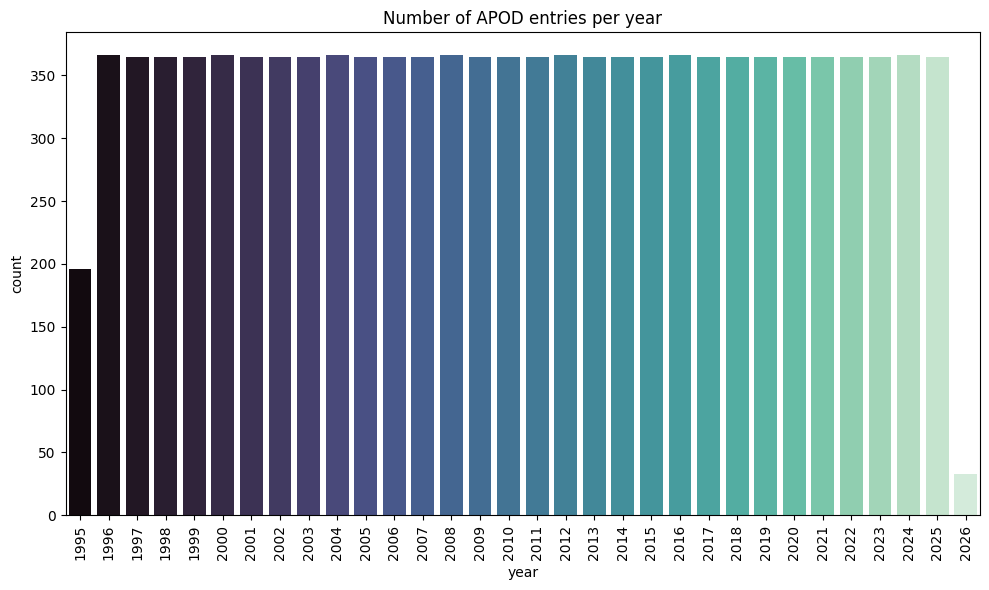

<Figure size 640x480 with 0 Axes>

In [8]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["year"] = df["date"].dt.year

plt.figure(figsize=(10, 6))
sns.countplot(x="year" , data=df , palette="mako")
plt.xticks(rotation=90)
plt.title("Number of APOD entries per year")
plt.xlabel("year")
plt.ylabel("count")
plt.tight_layout()
plt.show()
plt.savefig("apod_entries_per_year.png")

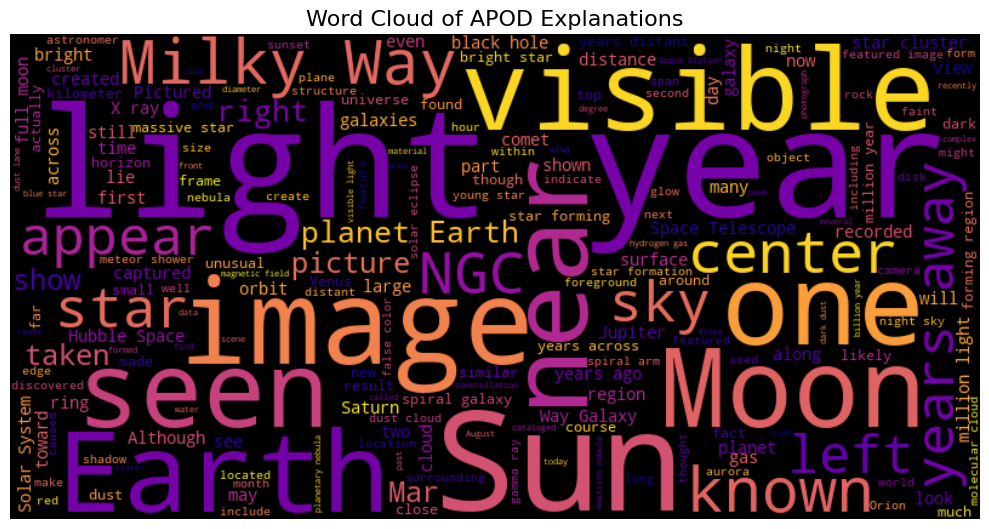

<Figure size 640x480 with 0 Axes>

In [9]:
from wordcloud import WordCloud
text = " ".join(df["explanation"].dropna().astype(str).tolist())
wordcloud = WordCloud(width=800, height=400, background_color="black", colormap="plasma").generate(text)

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation = "bilinear")
plt.axis("off")
plt.title("Word Cloud of APOD Explanations", fontsize=16)
plt.tight_layout()
plt.show()
plt.savefig("apod_explanation_wordcloud.png")

/var/folders/s9/9mvfxgrs1wb9r54tth0nzksm0000gn/T/ipykernel_82548/4095827035.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = "media_type" , data = df , palette="viridis")


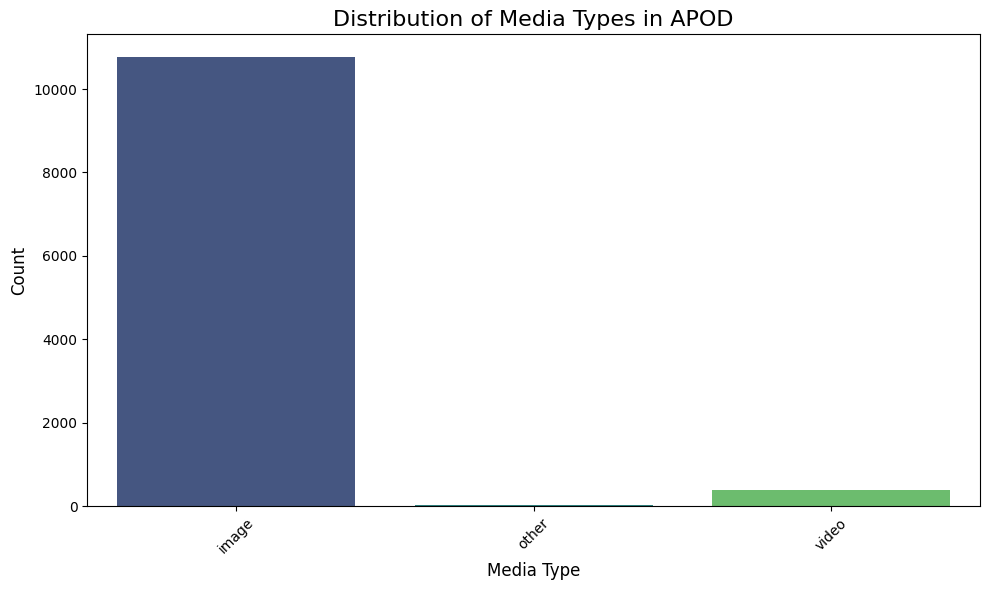

<Figure size 640x480 with 0 Axes>

In [10]:
plt.figure(figsize = (10, 6))
sns.countplot(x = "media_type" , data = df , palette="viridis")
plt.title("Distribution of Media Types in APOD" , fontsize = 16)
plt.xlabel("Media Type" , fontsize = 12)
plt.ylabel("Count" , fontsize = 12)
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()
plt.savefig("apod_media_type_distribution.png")

In [11]:
pip install torch torchvision

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [12]:
import warnings
warnings.filterwarnings("ignore")

import torch
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import requests
from io import BytesIO
import tqdm

In [13]:
resnet = models.resnet18(pretrained=True)
resnet.eval()
feature_extractor = torch.nn.Sequential(*list(resnet.children())[:-1])

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean = [0.485, 0.456, 0.406], std = [0.229, 0.224, 0.225])
])

def get_embedding(url):
    try:
        response = requests.get(url)
        img = Image.open(BytesIO(response.content)).convert("RGB")
        tensor = transform(img).unsqueeze(0)
        with torch.no_grad():
            embedding = feature_extractor(tensor).flatten()
        return embedding.numpy()
    except:
        return None

subset_df = df.sample(500 , random_state = 42).reset_index(drop = True)
embeddings = []

for url in tqdm.tqdm(subset_df["url"].tolist()):
    embeddings.append(get_embedding(url))
subset_df["image_embedding"] = embeddings

100%|██████████| 500/500 [1:03:43<00:00,  7.65s/it] 


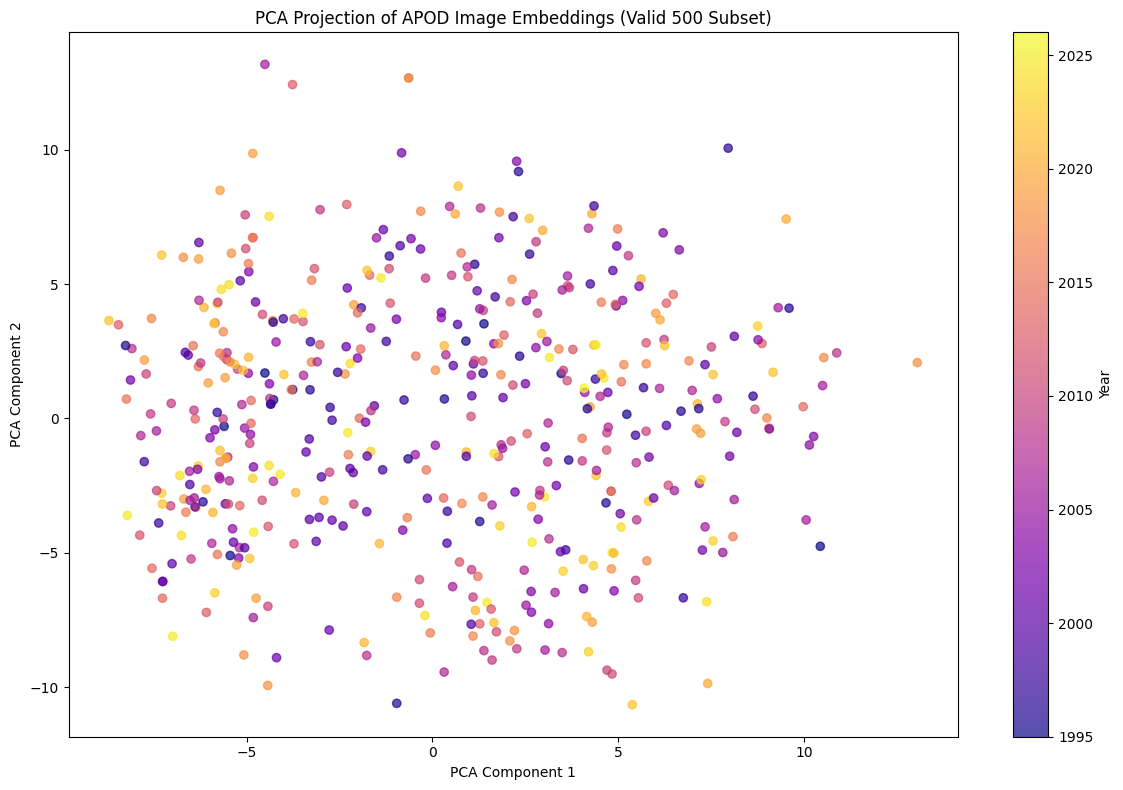

<Figure size 640x480 with 0 Axes>

In [14]:
from sklearn.decomposition import PCA

valid_df = subset_df.dropna(subset = ['image_embedding']).reset_index(drop = True)
valid_embeddings = np.vstack(valid_df["image_embedding"])

pca = PCA(n_components=2)
proj = pca.fit_transform(valid_embeddings)

plt.figure(figsize=(12,8))
plt.scatter(proj[:,0], proj[:,1], c=valid_df["year"].astype(int), cmap="plasma", alpha=0.7)
plt.colorbar(label="Year")
plt.title("PCA Projection of APOD Image Embeddings (Valid 500 Subset)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.tight_layout()
plt.show()
plt.savefig("apod_image_embedding_pca.png")

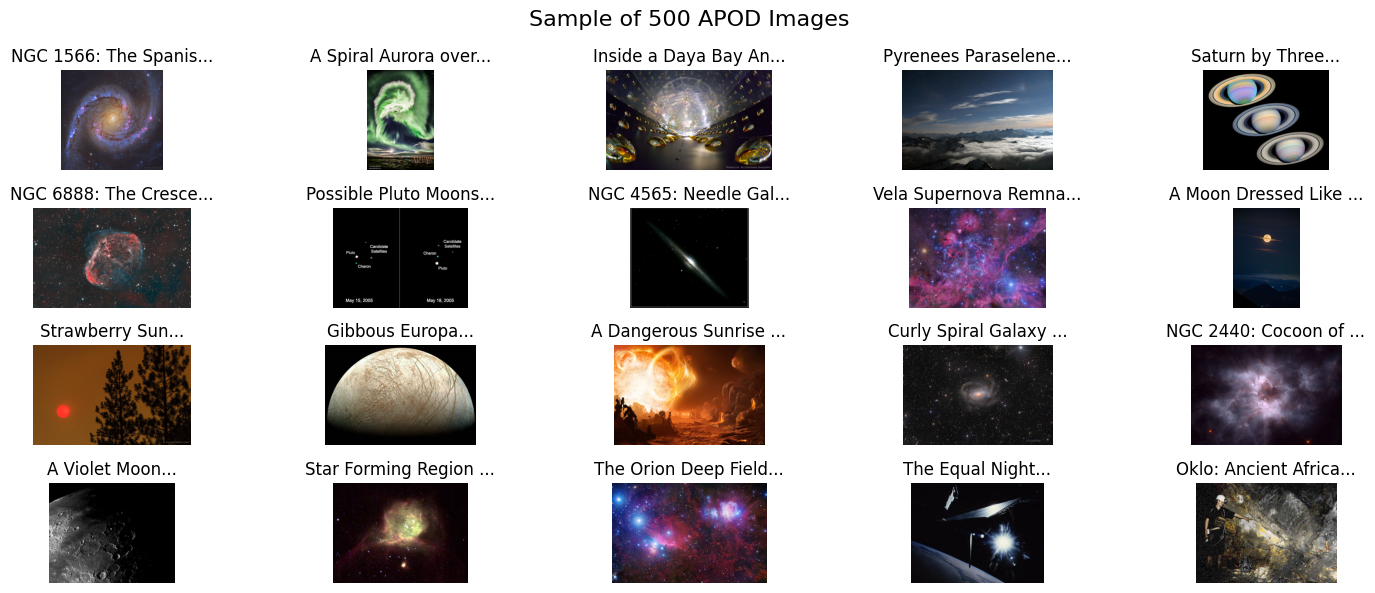

<Figure size 640x480 with 0 Axes>

In [15]:
fig, axes = plt.subplots(4, 5, figsize = (15, 6))
for ax , (_ , row) in zip(axes.flatten(), subset_df.iterrows()):
    try:
        img = Image.open(BytesIO(requests.get(row["url"], timeout=5).content)).convert("RGB")
        ax.imshow(img)
        ax.set_title(row["title"][:20]+"...")
        ax.axis("off")
    except:
        ax.axis("off")
plt.suptitle("Sample of 500 APOD Images", fontsize=16)
plt.tight_layout()
plt.show()
plt.savefig("sample_apod_images.png")

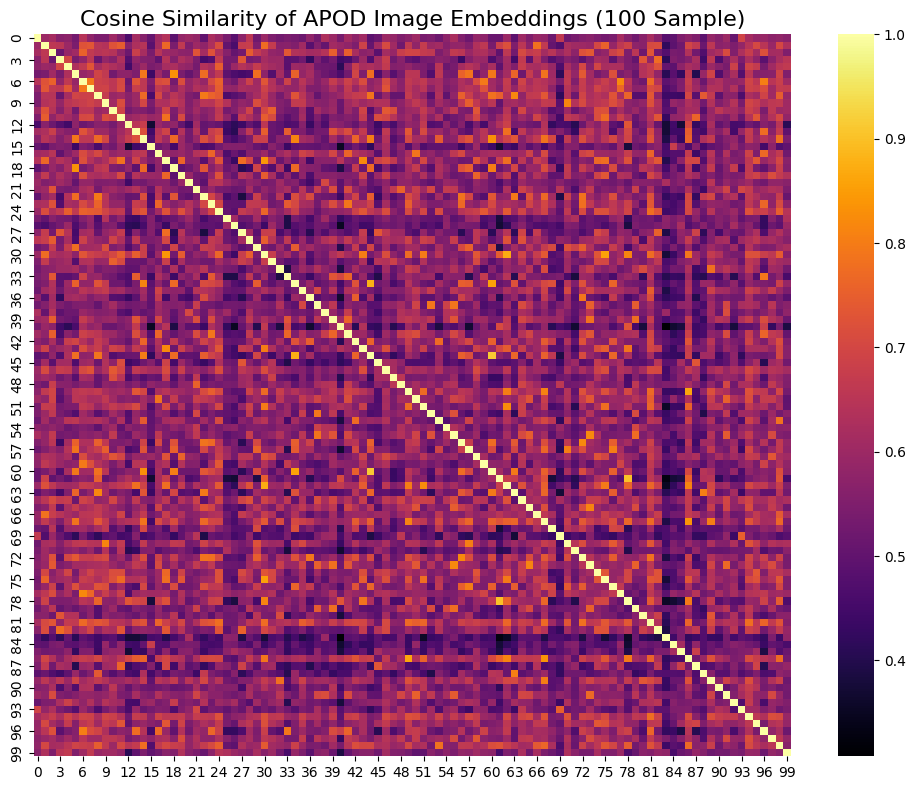

<Figure size 640x480 with 0 Axes>

In [16]:
from sklearn.metrics.pairwise import cosine_similarity

subset_small = subset_df.dropna(subset = ["image_embedding"]).sample(100 , random_state=42)
sim_matrix = cosine_similarity(np.vstack(subset_small["image_embedding"]))

plt.figure(figsize = (10, 8))
sns.heatmap(sim_matrix , cmap="inferno")
plt.title("Cosine Similarity of APOD Image Embeddings (100 Sample)", fontsize=16)
plt.tight_layout()
plt.show()
plt.savefig("apod_image_embedding_similarity.png")